In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import duckdb


In [2]:

# Load the Parquet file using DuckDB
con = duckdb.connect()
df = con.execute("""
    SELECT "Time Stamp", Load
    FROM read_parquet('./../../1_LIB/nyiso/nyiso_parquet/**/*.parquet')
""").df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [3]:
#need to double check zone coords
zone_coords = {
    "CAPITL": (42.65, -73.75),
    "CENTRL": (43.05, -76.15),
    "DUNWOD": (41.01, -73.78),
    "GENESE": (43.17, -77.61),
    "HUD VL": (41.70, -73.93),
    "MHK VL": (42.10, -75.91),
    "MILLWD": (41.13, -73.78),
    "N.Y.C.": (40.71, -74.01),
    "NORTH": (44.70, -73.45),
    "WEST": (42.89, -78.87)
}

In [4]:
df

,Time Stamp,Load
0,2001-05-26 00:00:00,985
1,2001-05-26 00:00:00,1461
2,2001-05-26 00:00:00,443
3,2001-05-26 00:00:00,830
4,2001-05-26 00:00:00,970
...,...,...
29303437,2025-10-01 00:30:00,644
29303438,2025-10-01 00:30:00,205
29303439,2025-10-01 00:30:00,5080
29303440,2025-10-01 00:30:00,527


In [5]:
df_total_load = df.groupby("Time Stamp", as_index=False)["Load"].sum()
df_total_load.rename(columns={"Time Stamp": "Time"}, inplace=True)


In [6]:
df_total_load

,Time,Load
0,2001-05-26 00:00:00,13859
1,2001-05-26 00:00:50,13761
2,2001-05-26 00:05:20,13718
3,2001-05-26 00:06:50,13622
4,2001-05-26 00:11:50,13551
...,...,...
2710904,2025-10-01 00:10:00,14720
2710905,2025-10-01 00:15:00,14663
2710906,2025-10-01 00:20:00,14628
2710907,2025-10-01 00:25:00,14612


In [ ]:
# Ensure the 'Time' column is a datetime type and set it as the index
df_total_load['Time'] = pd.to_datetime(df_total_load['Time'])
df_total_load.set_index('Time', inplace=True)

# Average minute load
df_hourly = df_total_load.resample('1min').mean().reset_index()
df_hourly = df_hourly.dropna().reset_index()



In [8]:
df_hourly

,index,Time,Load
0,0,2001-05-26 00:00:00,13810.0
1,5,2001-05-26 00:05:00,13718.0
2,6,2001-05-26 00:06:00,13622.0
3,11,2001-05-26 00:11:00,13551.0
4,16,2001-05-26 00:16:00,13565.0
...,...,...,...
2680604,12807370,2025-10-01 00:10:00,14720.0
2680605,12807375,2025-10-01 00:15:00,14663.0
2680606,12807380,2025-10-01 00:20:00,14628.0
2680607,12807385,2025-10-01 00:25:00,14612.0


In [9]:
df_total_load = df_hourly

In [10]:
# Split the data based on the year
train_data = df_total_load[df_total_load['Time'].dt.year.between(2001, 2021)]['Load']
val_data = df_total_load[df_total_load['Time'].dt.year == 2022]['Load']
test_data = df_total_load[df_total_load['Time'].dt.year.isin([2023, 2024, 2025])]['Load']

# Print the sizes of each split
print(f"Training data size: {len(train_data)}")
print(f"Validation data size: {len(val_data)}")
print(f"Testing data size: {len(test_data)}")

Training data size: 2279509
Validation data size: 107481
Testing data size: 293619


In [11]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(pd.DataFrame(train_data))
val_scaled = scaler.transform(pd.DataFrame(val_data))
test_scaled = scaler.transform(pd.DataFrame(test_data))

In [12]:
def create_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X[i:i + time_steps]
        Xs.append(v)
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 5
X_train, y_train = create_dataset(train_scaled, train_scaled, TIME_STEPS)
X_val, y_val = create_dataset(val_scaled, val_scaled, TIME_STEPS)
X_test, y_test = create_dataset(test_scaled, test_scaled, TIME_STEPS)
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(2279504, 5, 1) (2279504, 1)
(107476, 5, 1) (107476, 1)
(293614, 5, 1) (293614, 1)


In [13]:
print("NaNs in X_train:", np.isnan(X_train).sum())
print("NaNs in X_val:", np.isnan(X_val).sum())
print("NaNs in y_train:", np.isnan(y_train).sum())
print("NaNs in y_val:", np.isnan(y_val).sum())

NaNs in X_train: 0
NaNs in X_val: 0
NaNs in y_train: 0
NaNs in y_val: 0


In [14]:
subset_size = 40000
val_subset = 8749
X_train_sub = X_train[:subset_size]
y_train_sub = y_train[:subset_size]
X_val_sub = X_val[:val_subset]
y_val_sub = y_val[:val_subset]


In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error
# best_mae = float('inf')
# best_model = None

# for C in [0.1, 1, 10]:
#     for gamma in ['scale', 0.01, 0.001]:
#         for epsilon in [0.01, 0.1, 0.5, 1.0]:
#             print(f"C={C}, gamma={gamma}, epsilon={epsilon}")
#             model = SVR(kernel='rbf', C=C, gamma=gamma, epsilon=epsilon)
#             model.fit(X_train_sub.reshape(X_train_sub.shape[0], -1), y_train_sub)
#             preds = model.predict(X_val_sub.reshape(X_val_sub.shape[0], -1))
#             mae = mean_absolute_error(y_val_sub, preds)
#             print(f"val MAE={mae:.3f}")

#             if mae < best_mae:
#                 best_mae = mae
#                 best_model = model

# print("Best params found:", best_model.get_params())


: 

Best params found: {'C': 10, 'cache_size': 200, 'coef0': 0.0, 'degree': 3, 'epsilon': 0.01, 'gamma': 0.01, 'kernel': 'rbf', 'max_iter': -1, 'shrinking': True, 'tol': 0.001, 'verbose': False}

Best mae: 0.04994650252799576

In [ ]:
best_params = {'C': 10, 'cache_size': 200, 'coef0': 0.0, 'degree': 3, 'epsilon': 0.01, 'gamma': 0.01, 'kernel': 'rbf', 'max_iter': -1, 'shrinking': True, 'tol': 0.001, 'verbose': False}
best_model = SVR(**best_params)
best_model.fit(X_train.reshape(X_train.shape[0], -1), y_train)

C:\Users\sarah\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:

# Make predictions
train_pred = best_model.predict(X_train.reshape(X_train.shape[0], -1))
val_pred = best_model.predict(X_val.reshape(X_val.shape[0], -1))
test_pred = best_model.predict(X_test.reshape(X_test.shape[0], -1))

# Inverse scaling
train_pred_inv = scaler.inverse_transform(train_pred.reshape(-1, 1))
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))

val_pred_inv = scaler.inverse_transform(val_pred.reshape(-1, 1))
y_val_inv = scaler.inverse_transform(y_val.reshape(-1, 1))

test_pred_inv = scaler.inverse_transform(test_pred.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))


In [ ]:
# Evaluate the model
mae_train = mean_absolute_error(y_train_inv, train_pred_inv)
mae_test = mean_absolute_error(y_test_inv, test_pred_inv)
print("Mean Absolute Error on Training Data:", mae_train)
print("Mean Absolute Error on Testing Data:", mae_test)

Mean Absolute Error on Training Data: 212.21347312345026
Mean Absolute Error on Testing Data: 170.34232309986712


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np
import matplotlib as mpl
mpl.rcParams['animation.embed_limit'] = 100 

# Subset of your data
y_true = y_test_inv
y_pred = test_pred_inv
x = np.arange(len(y_true))

window = 100  # how many points to show at once
lag = 1       # number of steps prediction lags behind

fig, ax = plt.subplots(figsize=(10,6))
line_true, = ax.plot([], [], label="True Values", color="blue", alpha=0.7)
line_pred, = ax.plot([], [], label="Predictions", color="red", alpha=0.7)
ax.set_ylim(min(y_true.min(), y_pred.min())*0.95, max(y_true.max(), y_pred.max())*1.05)
ax.set_xlabel("Index")
ax.set_ylabel("Load")
ax.set_title("Predictions vs True Values (Trailing Window)")
ax.legend()

def update(frame):
    start = max(0, frame - window)
    end = frame
    line_true.set_data(x[start:end], y_true[start:end])
    
    # Prediction lags behind true values
    pred_start = max(0, frame - window - lag)
    pred_end = max(0, frame - lag)
    line_pred.set_data(x[pred_start:pred_end], y_pred[pred_start:pred_end])
    
    ax.set_xlim(x[start], x[end-1] if end > start else x[start]+1)
    return line_true, line_pred

ani = FuncAnimation(
    fig, update,
    frames=range(0, len(x), 10),   # every 10th frame
    interval=20, blit=True
)
HTML(ani.to_jshtml())



In [ ]:
mape = np.mean(np.abs((y_test_inv - test_pred_inv) / y_test_inv)) * 100
print(f"Testing MAPE: {mape:.2f}%")

eps = 1e-6
train_mape = np.mean(np.abs((y_train_inv- train_pred_inv) / (y_train_inv + eps))) * 100
print(f"Traingin MAPE: {mape:.2f}%")

mape = np.mean(np.abs((y_val_inv - val_pred_inv) / y_val_inv)) * 100
print(f"Val MAPE: {mape:.2f}%")



Testing MAPE: 1.00%
Traingin MAPE: 1.00%
Val MAPE: 0.95%


In [ ]:
from sklearn.metrics import r2_score

rmse = np.sqrt(mean_squared_error(y_test_inv, test_pred_inv))
print(f"Testing RMSE: {rmse}")

r2 = r2_score(y_test_inv, test_pred_inv)
print(f"Testing R2: {r2}")

Testing RMSE: 347.6162200976427
Testing R2: 0.9872711260207307


In [ ]:
# import joblib

# joblib.dump(best_model, "svr_model.joblib")


['svr_model.joblib']

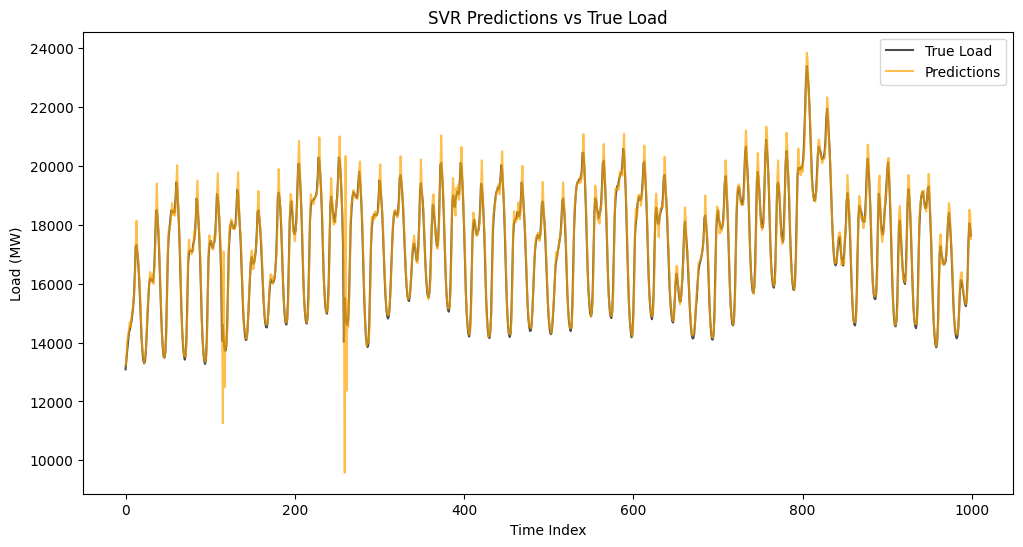

In [ ]:
subset_start = 0
subset_end = 1000
plt.figure(figsize=(12,6))
plt.plot(y_test_inv[subset_start: subset_end], label="True Load", color="black", alpha=0.7)
plt.plot(test_pred_inv[subset_start: subset_end], label="Predictions", color="orange", alpha=0.7)
plt.xlabel("Time Index")
plt.ylabel("Load (MW)")
plt.title("SVR Predictions vs True Load")
plt.legend()
plt.show()

In [ ]:
# from datetime import datetime
# import matplotlib.pyplot as plt
# import meteostat
# from meteostat import Point, Daily, Hourly

# start = datetime(2018, 1, 1, 0, 0)
# end = datetime(2018, 1, 1, 12, 0)

# # Create Point for Vancouver, BC
# vancouver = Point(42.65, -73.75)

# # Get daily data for 2018
# data = Hourly(vancouver, start, end)
# data = data.fetch()

# # Plot line chart including average, minimum and maximum temperature
# data